# Cramer-Lao Lower Bound

creating the lower bound for the detection on noisy, pixelated images

* dependent on noise, amplitude, z

From ChatGPT:


### Image Model
We model the observed pixel values as:
$$
x_i = \mu_i(\theta) + \epsilon_i
$$
where:
* $x_i$ is the observed intensity at pixel $i$,
* $\mu_i(\theta)$ is the expected intensity at pixel $i$, given the position parameter $\theta = (\theta_x, \theta_y)$,
* $\epsilon_i$ is a zero-mean Gaussian noise term with variance $\sigma^2$, i.e.,
$$
\epsilon_i \sim \mathcal{N}(0, \sigma^2)
$$
The expected intensity is given by:
$$
\mu_i(\theta) = A \cdot h_i(\theta) + B
$$
where:
* $A$ is the signal amplitude,
* $h_i(\theta)$ is the PSF centered at $\theta$,
* $B$ is the constant background intensity.


### Likelihood Function
Given the Gaussian noise model, the joint probability of observing the entire image is:
$$
p(\mathbf{x} | \theta) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( -\frac{(x_i - \mu_i(\theta))^2}{2 \sigma^2} \right)
$$
where $N$ is the total number of pixels.
The log-likelihood function is then:
$$
\log p(\mathbf{x} | \theta) = -\frac{N}{2} \log(2\pi \sigma^2) - \frac{1}{2 \sigma^2} \sum_{i=1}^N (x_i - \mu_i(\theta))^2
$$


### Fisher Information Matrix (FIM)
The Fisher Information Matrix is given by [[1]](https://en.wikipedia.org/wiki/Fisher_information#:~:text=If%20log%E2%80%89f(x;%20θ)%20is%20twice%20differentiable%20with%20respect%20to%20θ%2C%20and%20under%20certain%20additional%20regularity%20conditions%2C%20then%20the%20Fisher%20information%20may%20also%20be%20written%20as[7]):
$$
\mathcal{I}(\theta) = -\mathbb{E} \left[ \frac{\partial^2 \log p(\mathbf{x} | \theta)}{\partial \theta \partial \theta^T} \right]  = \frac{1}{\sigma^2} \sum_{i=1}^N \left( \frac{\partial \mu_i(\theta)}{\partial \theta} \cdot \frac{\partial \mu_i(\theta)}{\partial \theta^T} \right)
$$
where the expectation $\mathbb{E}$ removes the noise-dependent term since the noise has zero mean.


### Practical Form for 2D Position
For a 2D position parameter $\theta = (x, y)$, this becomes a 2x2 matrix:
$$
\mathcal{I}(\theta) = \frac{A^2}{\sigma^2} \sum_{i=1}^N \begin{bmatrix}
\left(\frac{\partial h_i}{\partial x} \right)^2 & \frac{\partial h_i}{\partial x} \cdot \frac{\partial h_i}{\partial y} \\
\frac{\partial h_i}{\partial x} \cdot \frac{\partial h_i}{\partial y} & \left(\frac{\partial h_i}{\partial y} \right)^2
\end{bmatrix}
$$

The CRLB for the variance of the position estimate is given by the inverse of this matrix:
$$
\text{Var}(\hat{\theta}) \geq \mathcal{I}(\theta)^{-1}
$$

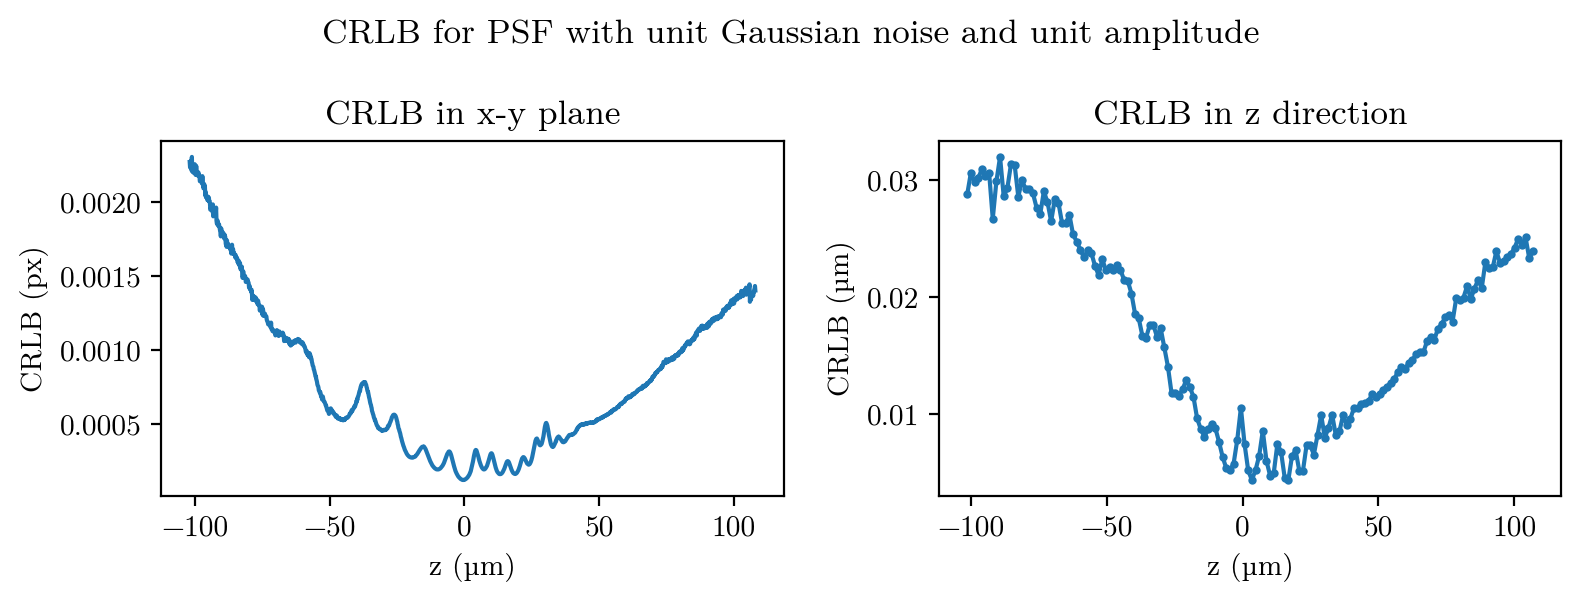

In [41]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift
from scipy.optimize import curve_fit

import sys
if ".." not in sys.path: sys.path.append("..")
import image_generator as ig
from tqdm import tqdm

# Parameters
AMP = 1              # Amplitude of the PSF
sigma_noise = 1       # Std dev of Gaussian noise
delta = 1e-2             # Small shift for numerical derivative
alpha = 0.01             # Scale factor for z-axis
psf = np.load("../ripples_downsampled.npy")  # Load PSF data

# Numerical derivatives w.r.t. x and y
def derivative(psf, z, axis, delta=1e-2, alpha=1e-2):
    if axis == 3:
        if z <1 and z > psf.shape[0]-2:
            raise ValueError("z must be between 1 and psf.shape[0]-2")
        psf_forward =  (psf[z].T*(1-alpha) + psf[z-1].T*alpha).T
        psf_backward = (psf[z].T*(1-alpha) + psf[z+1].T*alpha).T
        delta_z = 2*1.134*alpha #um
        return (psf_forward - psf_backward) / (2 * delta_z)

    shift_vec = [0, 0]
    shift_vec[axis] = delta
    psf_forward = (1-delta)*psf[z]+delta*np.roll(psf[z], shift=1, axis=axis)
    shift_vec[axis] = -delta
    psf_backward = (1-delta)*psf[z]+delta*np.roll(psf[z], shift=-1, axis=axis)
    return (psf_forward - psf_backward) / (2 * delta)


def compute_crlb(z):
    dh_dx = derivative(psf,z, axis=1)  # x-axis derivative
    dh_dy = derivative(psf,z, axis=0)  # y-axis derivative
    dh_dz = derivative(psf,z, axis=3)  # z-axis derivative

    # Compute Fisher Information Matrix (FIM)
    I_xx =  np.sum(dh_dx**2)
    I_yy =  np.sum(dh_dy**2)
    I_zz =  np.sum(dh_dz**2)


    I_xy =  np.sum(dh_dx * dh_dy)
    I_xz =  np.sum(dh_dx * dh_dz)
    I_yz =  np.sum(dh_dy * dh_dz)

    FIM = np.array([[I_xx, I_xy, I_xz],
                    [I_xy, I_yy, I_yz],
                    [I_xz, I_yz, I_zz]])

    CRLB = np.diag(np.linalg.inv(FIM))
    return sigma_noise/AMP *np.sqrt(CRLB)

# # Output results
# print("Fisher Information Matrix:\n", FIM)
# print("CRLB Covariance Matrix:\n", CRLB)



z_index = np.arange(1, 1566)
z_space = np.linspace(-102, 108, 1565)


std_x, std_y, std_z = np.array([compute_crlb(z_i) for z_i in z_index]).T
std_xy = np.sqrt((std_x**2+std_y**2)/2)

# Optional: visualize
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(z_space, std_xy)
plt.xlabel("z (µm)")
plt.ylabel("CRLB (px)")
plt.title("CRLB in x-y plane")
plt.subplot(1,2,2)
k=10
plt.plot(z_space[k//2:-k//2:k], np.convolve(std_z, np.ones(k)/k, mode='same')[k//2:-k//2:k], ".-",ms=4)
plt.xlabel("z (µm)")
plt.ylabel("CRLB (µm)")
plt.title("CRLB in z direction")
plt.suptitle("CRLB for PSF with unit Gaussian noise and unit amplitude")
plt.tight_layout()
plt.show()

sampling absolute noise levels for different SNRs

In [42]:


ripple_params = {"label":"Ripple", "i":("gaussian", [0.75,0.25]), "z":[0,1567], "n":(30,90)}
parameter_list = [ripple_params, ]
image_size = 540,640            # Dimension 


snr_range = [1,18]
snrlevels = np.linspace(*snr_range, 18)
mean_noise = []
median_noise = []
for snr in snrlevels:
    print(f"Simulating for SNR: {snr}")
    noise = []
    numbers = []
    for i in range(500):
        n = np.random.randint(*ripple_params["n"])
        z = np.random.randint(*ripple_params["z"], n)
        ripples = psf[z]-2e4 #shape (n, 540, 640)
        intensities = np.random.normal(*ripple_params["i"][1], n)
        signal = np.max(np.abs(intensities*ripples.T).T, (1,2)) #max difference from background for each particle
        noise_std = np.mean(signal) / snr
        noise.append(noise_std)
        numbers.append(n)
    noise = np.array(noise)
    mean_noise.append(noise.mean())
    median_noise.append(np.median(noise))

Simulating for SNR: 1.0
Simulating for SNR: 2.0
Simulating for SNR: 3.0
Simulating for SNR: 4.0
Simulating for SNR: 5.0
Simulating for SNR: 6.0
Simulating for SNR: 7.0
Simulating for SNR: 8.0
Simulating for SNR: 9.0
Simulating for SNR: 10.0
Simulating for SNR: 11.0
Simulating for SNR: 12.0
Simulating for SNR: 13.0
Simulating for SNR: 14.0
Simulating for SNR: 15.0
Simulating for SNR: 16.0
Simulating for SNR: 17.0
Simulating for SNR: 18.0


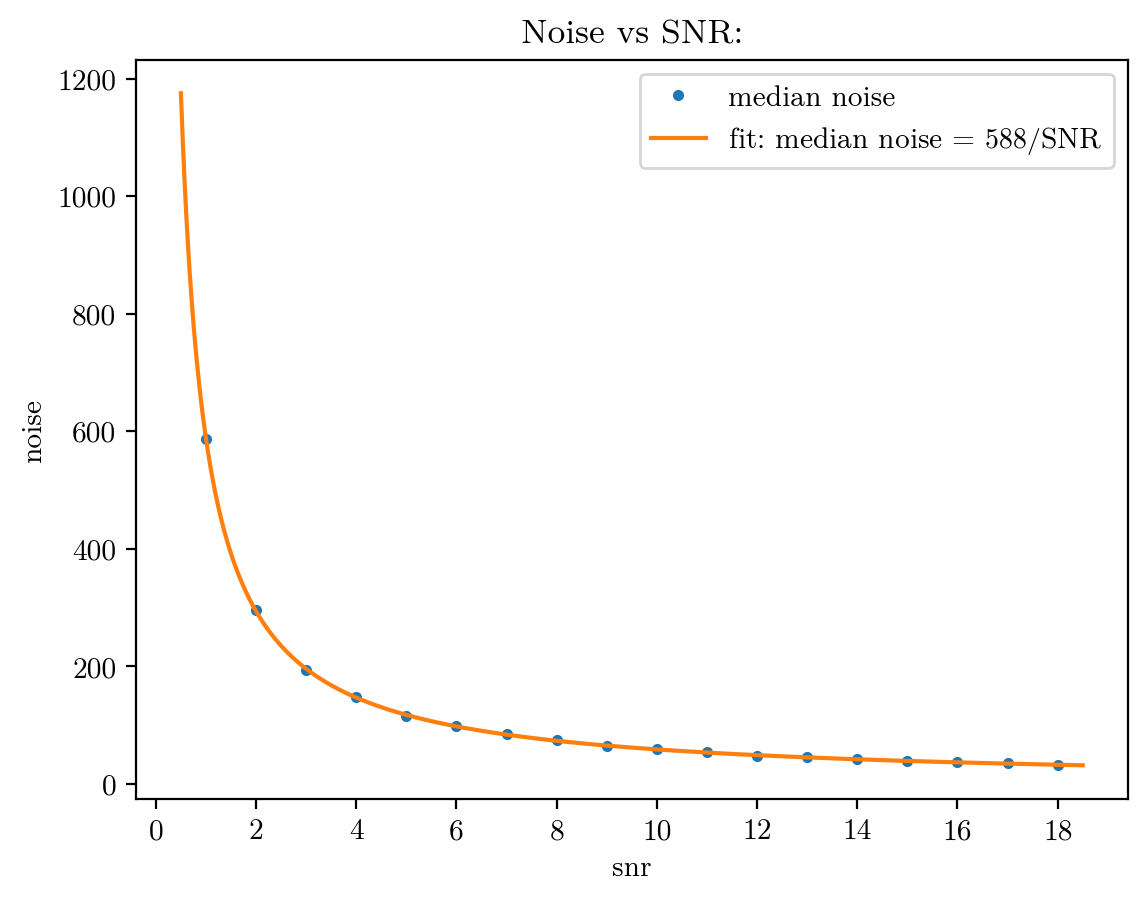

In [43]:
def func(x, a):
    return a/x
plt.plot(snrlevels, median_noise, ".", label="median noise")
params, _ = curve_fit(func, snrlevels, median_noise)
snr_space = np.linspace(snr_range[0]-0.5, snr_range[1]+0.5, 1000)
plt.plot(snr_space, func(snr_space, *params), label=fr"fit: median noise = ${params[0]:.3g} /$SNR")

plt.xlabel("snr")
plt.ylabel("noise")
plt.legend()
plt.title(fr"Noise vs SNR:")
plt.xticks(np.arange(0, 20, 2))
plt.show()

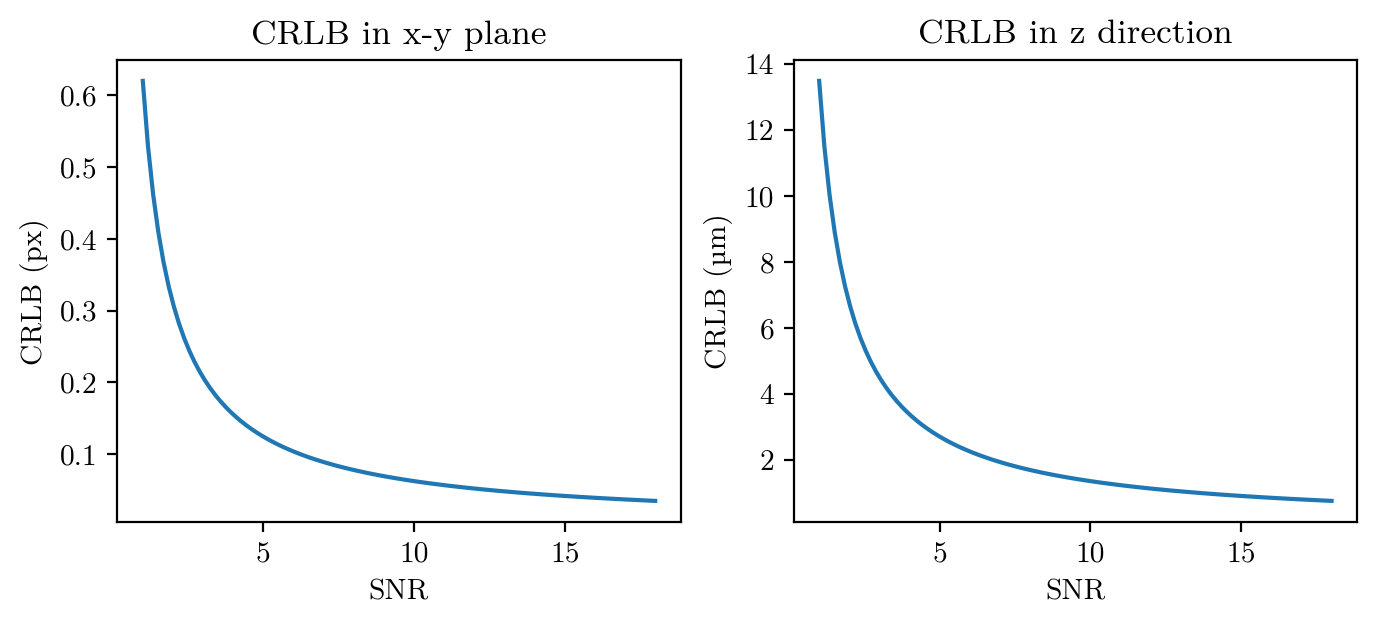

In [44]:
amp=0.75
snr_space = np.linspace(1,18,100)
sigma_noise = params[0]/snr_space # from fit of snr to noise

mean_lb_z = sigma_noise/amp * np.mean(std_z)
mean_lb_xy = sigma_noise/amp * np.mean(std_xy)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(snr_space, mean_lb_xy, label="xy")
plt.xlabel("SNR")
plt.ylabel("CRLB (px)")
plt.title("CRLB in x-y plane")

plt.subplot(1,2,2)
plt.plot(snr_space, mean_lb_z, label="z")
plt.xlabel("SNR")
plt.ylabel("CRLB (µm)")
plt.title("CRLB in z direction")
plt.show()